# 01 - Exploratory Data Analysis

**Dataset:** Amazon Reviews 2023 — Video_Games category

**Files:** data/raw/video_games_reviews_100000.parquet, data/raw/video_games_metadata_100000.parquet

**Goal:** Understand data quality and distribution to inform cleaning/filtering decisions in src/data/clean.py and src/data/split.py

## 1. Load and Inspect Raw Data

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from src.data.clean import iterative_filter

pd.set_option('display.max_columns', 100)
plt.style.use('ggplot')

reviews_df = pd.read_parquet("../data/raw/Video_Games_reviews_100000.parquet")
metadata_df = pd.read_parquet("../data/raw/Video_Games_metadata_100000.parquet")

print(reviews_df.shape, metadata_df.shape)
print(reviews_df.columns)
print(reviews_df.dtypes)
print(metadata_df.columns)
print(metadata_df.dtypes)

(3394737, 10) (100000, 16)
Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='str')
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together', 'subtitle', 'author'],
      dtype='str')
main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
description         object
price                  str
images              object
videos              object
store                  

In [5]:
reviews_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,4.0,It’s pretty sexual. Not my fav,I’m playing on ps5 and it’s interesting. It’s...,[],B07DJWBYKP,B07DK1H3H5,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1608186804795,0,True
3,5.0,Great alt to pro controller,"These work great, They use batteries which is ...",[],B07GXJHRVK,B0BCHWZX95,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,1577637634017,0,True
4,5.0,solid product,I would recommend to anyone looking to add jus...,[],B00HUWA45W,B00HUWA45W,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,1427591932000,0,True
5,3.0,love all the amazing colors but the black is r...,love all the amazing colors but the black is r...,[],B016Y2BVKA,B073SC6V1D,AHXSBZT52TCPZUBVCBRICTHWUCBA,1518124539574,0,True
6,5.0,Will use again,Instant delivery!,[],B004RMK57U,B004RMK57U,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1602937709361,0,True


In [6]:
metadata_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Video Games,WRC 7 - PlayStation 4,4.2,161,[New official cars! Powerful rally behemoths f...,"[The racing game dominating the genre is back,...",None,"{'hi_res': [None, 'https://m.media-amazon.com/...","{'title': ['WRC 7 - PlayStation 4'], 'url': ['...",Maximum Games,"[Video Games, PlayStation 4, Games]","{""Release date"": ""October 3, 2017"", ""Best Sell...",B0754RPTB7,NaN,NaN,NaN
1,Video Games,"TOPAD Remote for PS4 Controller,Gamepad Joysti...",3.8,41,[🎮【Ergonomic Design & Comfortable】TOPAD ymir b...,[],24.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': ['Bang for Buck', 'Awesome', 'Great ...",TOPAD,"[Video Games, PlayStation 4, Accessories, Remo...","{""Best Sellers Rank"": {""Video Games"": 27896, ""...",B0BW6QSLXM,NaN,NaN,NaN
2,Video Games,"GEEKERA Charging Dock for Oculus Quest 2, Magn...",4.5,73,[Effortless Magnetic Charging: Experience hass...,[],48.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",GEEKERA,"[Video Games, PC, Virtual Reality, Headsets]","{""Best Sellers Rank"": {""Video Games"": 2202, ""P...",B0BZD7TTVZ,NaN,NaN,NaN
3,All Electronics,Switch Lite Case - innoAura 15 in 1 Switch Lit...,4.8,848,[【15 in 1 NS Switch Lite Bundle】-This Switch a...,[],23.99,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': ['Switch Lite Case ', 'ProCase Ninte...",innoAura,"[Video Games, Nintendo Switch, Accessories, Ca...","{""Package Dimensions"": ""9.02 x 5.91 x 2.52 inc...",B0B2PR256F,NaN,NaN,NaN
4,Cell Phones & Accessories,"FANPL Design for Nintendo Switch OLED Case, Cu...",3.7,4,"[【Exclusive pattern】: FANPL pattern design, re...","[【Features】, ✔️FANPL pattern design shows more...",None,{'hi_res': ['https://m.media-amazon.com/images...,"{'title': [], 'url': [], 'user_id': []}",FANPL,"[Video Games, Nintendo Switch, Accessories, Ca...","{""Package Dimensions"": ""8.19 x 4.33 x 1.3 inch...",B09WTQKH6P,NaN,NaN,NaN


## 2. Missing Values

In [8]:
reviews_df.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [9]:
metadata_df.isnull().sum()

main_category        8102
title                   0
average_rating          0
rating_number           0
features                0
description             0
price                   0
images                  0
videos                  0
store                3186
categories              0
details                 0
parent_asin             0
bought_together    100000
subtitle            99740
author              99805
dtype: int64

In [20]:
metadata_df["description"].apply(lambda x: len(x) == 0).mean()

np.float64(0.37767)

In [19]:
metadata_df["features"].apply(lambda x: len(x) == 0).mean()

np.float64(0.28812)

In [15]:
review_items = set(reviews_df["parent_asin"])
meta_items = set(metadata_df["parent_asin"])

missing_from_meta = review_items - meta_items
print(f"{len(missing_from_meta)} items in reviews but missing from metadata")
print(f"{len(missing_from_meta) / len(review_items):.4%} of unique review items affected")

0 items in reviews but missing from metadata
0.0000% of unique review items affected


### 3. Interaction Distribution

In [14]:
user_counts = reviews_df.groupby("user_id").size()
item_counts = reviews_df.groupby("parent_asin").size()

print(user_counts.describe())
print((user_counts == 1).mean())
print("########")
print(item_counts.describe())
print((item_counts == 1).mean())

count    2.193964e+06
mean     1.547308e+00
std      1.980513e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.000000e+02
dtype: float64
0.7521417853711364
########
count    99986.000000
mean        33.952123
std        205.014600
min          1.000000
25%          1.000000
50%          4.000000
75%         14.000000
max      18105.000000
dtype: float64
0.2770387854299602


**Users are extremely sparse:**
- 2,193,964 unique users, mean of 1.55 reviews/user
- 75.2% of users have exactly 1 review (median = 1, max = 500)
- This is typical of e-commerce data (most people review a product once, if at all)
  but means most users have almost no history to learn a preference from

**Items are richer but still long-tailed:**
- 99,986 unique items, mean of 33.95 reviews/item, but median is only 4
- 27.7% of items have only 1 review (max = 18,105 — a handful of extremely popular items
  dominate the distribution)
- The large gap between mean and median confirms a long-tail / power-law shape typical of Amazon data

**Decision: standard cutoffs (e.g. 5+ per user) don't apply here**
- A 5+ review cutoff would eliminate ~75%+ of users, which is too aggressive for this dataset
- Chose to filter with: `min_user_interactions = 2`, `min_item_interactions = 5`
- Filtering will be applied iteratively (removing low-count users can push some items
  below threshold, and vice versa) until the dataset stabilizes
- After filtering: [FILL IN — retained X reviews, Y users, Z items]

In [27]:
reviews_filtered = iterative_filter(reviews_df, min_user=2, min_item=5)

user_counts = reviews_filtered.groupby("user_id").size()
item_counts = reviews_filtered.groupby("parent_asin").size()

print(user_counts.describe())
print((user_counts == 1).mean())
print("########")
print(item_counts.describe())
print((item_counts == 1).mean())

Iteration 1: 3394737 -> 1690667 reviews
Iteration 2: 1690667 -> 1641332 reviews
Iteration 3: 1641332 -> 1627000 reviews
Iteration 4: 1627000 -> 1625350 reviews
Iteration 5: 1625350 -> 1624863 reviews
count    511253.000000
mean          3.178197
std           3.355208
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         462.000000
dtype: float64
6.063534101511385e-05
########
count    32782.000000
mean        49.565707
std        164.063838
min          4.000000
25%          7.000000
50%         14.000000
75%         34.000000
max       9303.000000
dtype: float64
0.0


## 4. Rating Distribution

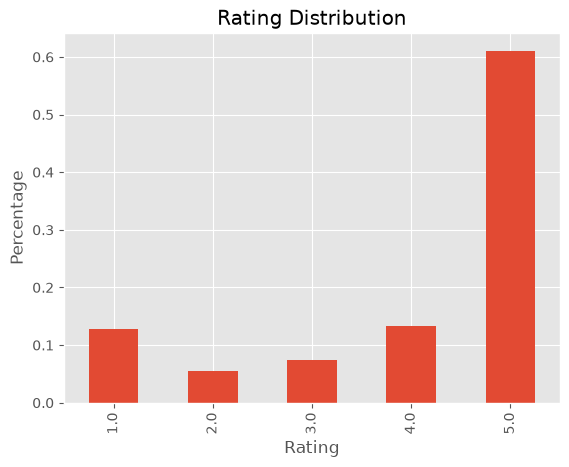

In [17]:
ax = reviews_df["rating"].value_counts(normalize=True).sort_index().plot(kind="bar", title="Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Percentage")
plt.show()

- Ratings are heavily skewed toward 5 stars (~55-60% of all reviews)
- 4-star is a distant second; 1-3 star ratings are each much smaller and roughly similar in size
- This "J-shaped" distribution is typical of Amazon review data — reviews skew positive,
  with a smaller spike of negative reviews and underrepresented middle ratings

**Decision:** Frame the recommendation task as **implicit feedback** (interacted vs. not),
rather than explicit rating prediction. This avoids the class-imbalance problem of the
ratings themselves and matches the standard approach for two-tower retrieval models.
Ratings ≥4 will be treated as strong positive signals; ratings ≤2 may be excluded from
positive interactions or treated separately (e.g., as negative signal) during training data
construction.

## 5. Time Range and Volume over time

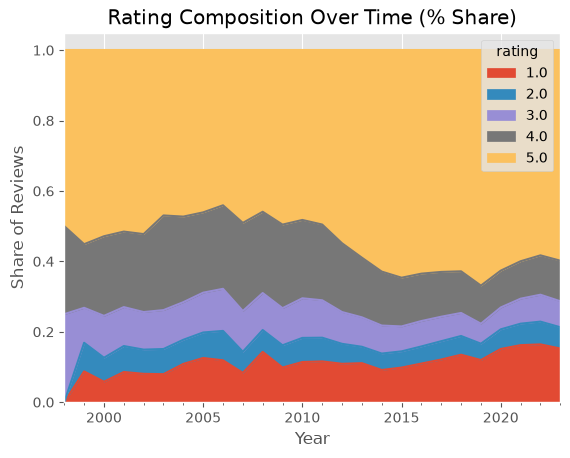

In [27]:
reviews_df["timestamp"] = pd.to_datetime(reviews_df["timestamp"], unit="ms")
rating_over_time = reviews_df.set_index("timestamp").groupby(
    [pd.Grouper(freq="YE"), "rating"]
).size().unstack()

rating_over_time_pct = rating_over_time.div(rating_over_time.sum(axis=1), axis=0)

ax = rating_over_time_pct.plot(kind="area", stacked=True)
ax.set(xlabel="Year", ylabel="Share of Reviews", title="Rating Composition Over Time (% Share)")
plt.show()

- 5-star share is NOT monotonically declining; it follows a U-then-rise pattern:
  - ~50-55% in the late 1990s/early 2000s
  - dips to its lowest point (~44-47%) in the mid-2000s
  - rises substantially from 2012 onward, peaking at ~63-67% around 2014-2019
  - eases slightly to ~58-63% in 2020-2023, still well above the mid-2000s low
- Overall, recent years (2014-2023) show a higher 5-star share than the dataset's
  earliest years, not lower
- **Implication:** rating composition is non-stationary over time, but the direction
  is toward more positive skew in recent years, not less — worth accounting for
  when interpreting train/val/test splits, since the test set (most recent) will
  likely have a higher positive-interaction rate than mid-2000s-heavy training slices

In [39]:
reviews_df.set_index("timestamp").resample("ME").size().tail(10)

timestamp
2022-12-31    29561
2023-01-31    33569
2023-02-28    24105
2023-03-31    27710
2023-04-30    17509
2023-05-31    10412
2023-06-30     6942
2023-07-31     5961
2023-08-31     3971
2023-09-30      270
Freq: ME, dtype: int64

### Temporal Analysis — Finalized Trim & Split
- Data collection cutoff artifact confirmed: review volume drops sharply from
  May 2023 onward (17,509 in April → 270 in September), consistent with incomplete
  final months rather than a real activity decline
- **Trim decision:** exclude all data from 2023-05-01 onward
- **Split cutoffs:** train < 2021-01-01, val 2021-01-01 to 2022-06-01, test >= 2022-06-01

## 6. ID overlap between reviews and metadata

In [28]:
review_items = set(reviews_df["parent_asin"])
meta_items = set(metadata_df["parent_asin"])

print(f"{len(review_items - meta_items)} items in reviews but missing from metadata")
print(f"{len(meta_items - review_items)} items in metadata with no reviews")

0 items in reviews but missing from metadata
14 items in metadata with no reviews


- 0 items in reviews are missing from metadata — full referential integrity from reviews → metadata
- 14 items exist in metadata with no associated reviews (negligible, ~0.014% of ~100k items)

**Decision:** No special handling needed. The 14 review-less metadata items will be naturally excluded
during the interaction-filtering step in clean.py, since metadata is filtered down to
items present in the cleaned reviews table.

## 7. Text length distribution

In [31]:
metadata_df["title"].str.len().describe()

count    100000.000000
mean         85.725360
std          58.279535
min           0.000000
25%          36.000000
50%          66.000000
75%         134.000000
max         620.000000
Name: title, dtype: float64

In [33]:
metadata_df["description"].apply(lambda x: len(" ".join(x)) if len(x) > 0 else 0).describe()

count    100000.00000
mean        575.91353
std        1219.17399
min           0.00000
25%           0.00000
50%         154.00000
75%         690.00000
max       93558.00000
Name: description, dtype: float64

In [34]:
(metadata_df["title"].str.len() == 0).sum()

np.int64(5)

**Title:**
- 100,000 items, mean length 85.7 chars, median 66, max 620
- Only 5 items (0.005%) have a completely empty title — negligible, but must be handled
  explicitly since these items have no text from title to build an embedding from

**Description (measuring actual joined text content, not list repr):**
- Mean 575.9 chars, median 154, max 93,558
- 37.77% of items have an empty description (confirmed consistent with earlier finding)
- When present, descriptions are often substantial (median 154 chars)

**Features:**
- 28.81% of items have an empty features list (from earlier check)

**Decision:** Build `item_text` per item as a fallback chain: title → + description
(if present) → + features (if present). For the 5 items with empty titles AND
(potentially) empty description/features, item_text may end up empty — these items
should be flagged and excluded from the embedding step, since no text-based recommendation
or search signal is possible for them.

In [36]:
empty_title_items = metadata_df[metadata_df["title"].str.len() == 0]
empty_title_items[["title", "description", "features"]]

,title,description,features
51387,,[],[]
51459,,[],[]
67796,,[Build up your Fishdom! Progress through chall...,"[Challenging and fun match-3 gameplay, Unlimit..."
94211,,[The Afterglow LVL Headset Adapter allows you ...,[Designed exclusively for the Xbox One Wireles...
98676,,[Officially Designed for Sony PlayStation Pro ...,[Officially Licensed by Sony PlayStation - Des...



**Empty title investigation (5 items):**
- 3 of 5 have usable description/features text — rescued by the item_text fallback chain
- 2 of 5 (items 51387, 51459) have NO usable text in title, description, or features
  — these will be excluded from search/embedding entirely, as no text signal exists

**Final Decision:** item_text fallback chain (title → description → features) successfully
handles all but 2 items in the dataset. Those 2 items will be flagged and dropped during
the cleaning step, as they cannot participate in any text-based search or recommendation.

## 8. Summary of Decisions

This section consolidates every finding and decision from the EDA above into a single
reference for `src/data/clean.py` and `src/data/split.py`.

### Dataset
- Amazon Reviews 2023 — Video_Games category
- 2,193,964 unique users, 99,986 unique items, ~4.6M raw reviews

### Referential Integrity (Section 6)
- 0 items in reviews are missing from metadata — full integrity from reviews → metadata
- 14 items in metadata have no reviews — negligible, naturally excluded during interaction filtering
- `drop_reviews_without_metadata` is effectively a no-op; keep as a lightweight assertion/safety check only

### Interaction Filtering (Section 3)
- 75.2% of users have only 1 review; 27.7% of items have only 1 review — dataset is extremely sparse
- Standard cutoffs (e.g. 5+ per user) are too aggressive and would discard most users
- **Chosen thresholds:** `min_user_interactions = 2`, `min_item_interactions = 5`
- Filtering applied iteratively (`iterative_filter` in clean.py) since removing users can
  drop items below threshold and vice versa
- Cold-start (sparse users/items) will remain a real characteristic even after filtering —
  to be acknowledged explicitly in evaluation, not treated as fully solved

### Rating Distribution (Section 4)
- Ratings are heavily skewed toward 5 stars (~55-60% overall)
- **Decision:** frame the task as implicit feedback (interacted vs. not) rather than
  explicit rating regression, to avoid class-imbalance issues
- Ratings ≥4 treated as strong positive signals; ratings ≤2 may be excluded from positive
  interactions or treated as negative signal during training data construction

### Temporal Analysis (Section 5)
- Review volume is very low pre-2013, grows sharply after, with visible seasonal spikes
- Final period in the raw data shows an artifact drop-off (likely incomplete data collection
  cutoff) — **must confirm exact trim point before splitting**
- Rating composition is non-stationary: 5-star share dipped in mid-2000s (~44-47%), then
  rose substantially from 2012 onward, peaking ~63-67% (2014-2019), easing slightly in
  2020-2023 (~58-63%) — recent years are MORE positively skewed than early years, not less
- **Decision:** use explicit calendar-based cutoffs for train/val/test (not row-count
  quantiles), since volume and rating composition are both uneven over time
- **Decision:** report train/val/test positive-rate composition explicitly rather than
  assuming it's stationary across splits
- **Split cutoffs:** train < 2021-01-01, val 2021-01-01 to 2022-06-01, test >= 2022-06-01

### Text Quality (Section 7)
- Title: 100% coverage except 5 items (0.005%) with empty titles
- Description: 37.77% of items have no description; when present, median 154 chars
- Features: 28.81% of items have no features list
- Of the 5 empty-title items, 3 are rescued by description/features; only 2 items
  (out of 100,000) have zero usable text anywhere
- **Decision:** build `item_text` as a fallback chain: title → + description (if present)
  → + features (if present)
- **Decision:** exclude the 2 fully-empty items from search/embedding entirely

### Summary — What `clean.py` needs to implement
1. Assert/verify referential integrity (reviews → metadata) — expect near-zero mismatches
2. Iteratively filter interactions: min_user_interactions=2, min_item_interactions=5
3. Build `item_text` via fallback chain (title → description → features)
4. Drop items with fully empty item_text (expect ~2 items)
5. Trim incomplete trailing time period before handing off to split.py

### Summary — What `split.py` needs to implement
1. Use explicit calendar-based cutoffs (not quantiles) for train/val/test
2. Report interaction counts and positive-rate (rating≥4 share) per split to confirm
   composition is documented, even though it will differ across splits